# **Heart Failure Prediction Analysis - Logistic Regression, Random Forest, XGBoost, SVM, & Naive Bayes**

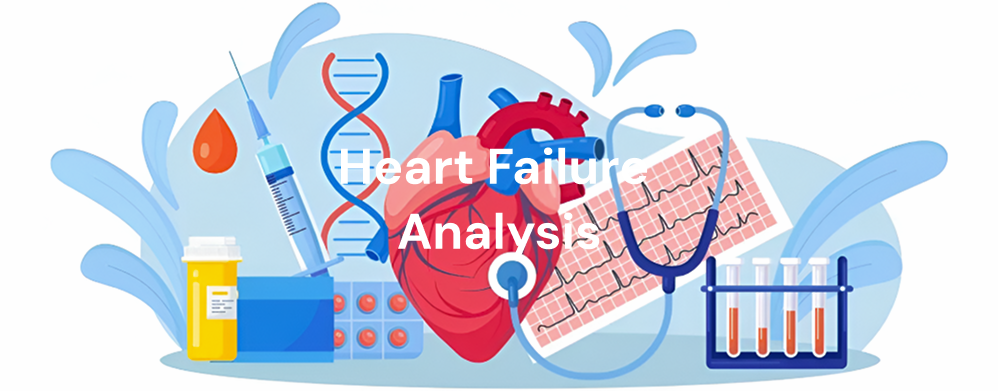

## **Problem Description**

---

According to the Fedesoriano 2021, the Cardiovasular diseases represent the world’s leading cause of death, taking estimate 17.9 million lives every year, this accounts for 31% of all deaths around the world. The early detection remains challenging, as traditional diagnostic approaches often miss subtle warning signs until conditions become critical. Using a comprehensive dataset of 918 patient records with 11 clinical features including symptoms, demographics, and diagnostic test results, this heart failure examines addresses heart disease prediction. Our objective is to create predictive models capable of precisely identifying heart disease risk-ridden patients. We therefore believe that by means of timely medical intervention, healthcare professionals can intervene early and maybe save lives.

In [1]:
# Uncomment the following line to install the required packages

#pip install numpy pandas scipy matplotlib seaborn scikit-learn xgboost

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report, average_precision_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, RobustScaler
from xgboost import XGBClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')

/kaggle/input/heart-failure-prediction/heart.csv


## 1.0 Data Understanding & Preprocessing

In [3]:
# Load the dataset
df = pd.read_csv('/kaggle/input/heart-failure-prediction/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# Check for missing values
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
# Check for data quality issues - zero values in medical parameters are suspicious
print(f"RestingBP = 0: {(df['RestingBP'] == 0).sum()}")
print(f"Cholesterol = 0: {(df['Cholesterol'] == 0).sum()}")

RestingBP = 0: 1
Cholesterol = 0: 172


In [8]:
# Check target variable distribution
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [9]:
# Create working copy
df_clean = df.copy()

In [10]:
# Handle zero cholesterol values - impute with median by gender (clinical practice)
median_chol_male = df_clean[(df_clean['Sex'] == 'M') & (df_clean['Cholesterol'] > 0)]['Cholesterol'].median()
median_chol_female = df_clean[(df_clean['Sex'] == 'F') & (df_clean['Cholesterol'] > 0)]['Cholesterol'].median()

df_clean.loc[(df_clean['Cholesterol'] == 0) & (df_clean['Sex'] == 'M'), 'Cholesterol'] = median_chol_male
df_clean.loc[(df_clean['Cholesterol'] == 0) & (df_clean['Sex'] == 'F'), 'Cholesterol'] = median_chol_female

# Handle zero RestingBP - impute with overall median
if (df_clean['RestingBP'] == 0).sum() > 0:
    median_bp = df_clean[df_clean['RestingBP'] > 0]['RestingBP'].median()
    df_clean.loc[df_clean['RestingBP'] == 0, 'RestingBP'] = median_bp

# Verify cleaning worked
print(f"After cleaning - Cholesterol zeros: {(df_clean['Cholesterol'] == 0).sum()}")
print(f"After cleaning - RestingBP zeros: {(df_clean['RestingBP'] == 0).sum()}")

After cleaning - Cholesterol zeros: 0
After cleaning - RestingBP zeros: 0


In [11]:
df_clean.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.538126,242.810458,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.990127,53.474043,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,234.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 1.1 Feature Engineering

In [12]:
# Here, I did binary encoding for better model performance
# I encoding Male=1, Female=0 and Yes=1, No=0
df_clean['Sex_Male'] = (df_clean['Sex'] == 'M').astype(int)
df_clean['ExerciseAngina_Yes'] = (df_clean['ExerciseAngina'] == 'Y').astype(int)

In [13]:
# Ordinal encoding for ST_Slope - medical significance: Down < Flat < Up
st_slope_map = {'Down': 0, 'Flat': 1, 'Up': 2}
df_clean['ST_Slope_Encoded'] = df_clean['ST_Slope'].map(st_slope_map)

In [14]:
# One-hot encoding for ChestPainType - nominal categorical
chest_pain_dummies = pd.get_dummies(df_clean['ChestPainType'], prefix='ChestPain', drop_first=True)
df_clean = pd.concat([df_clean, chest_pain_dummies], axis=1)

In [15]:
# One-hot encoding for RestingECG
ecg_dummies = pd.get_dummies(df_clean['RestingECG'], prefix='ECG', drop_first=True)
df_clean = pd.concat([df_clean, ecg_dummies], axis=1)

In [16]:
df_clean

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex_Male,ExerciseAngina_Yes,ST_Slope_Encoded,ChestPain_ATA,ChestPain_NAP,ChestPain_TA,ECG_Normal,ECG_ST
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,1,0,2,True,False,False,True,False
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0,0,1,False,True,False,True,False
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,1,0,2,True,False,False,False,True
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,0,1,1,False,False,False,True,False
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,1,0,2,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,1,0,1,False,False,True,True,False
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,1,0,1,False,False,False,True,False
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,1,1,1,False,False,False,True,False
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,0,0,1,True,False,False,False,False


### 1.2 Feature Selection

In [17]:
# I select relevant features for heart disease prediction
# Keep original numerical features that are medically relevant
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [18]:
# I keep engineered binary and encoded features
engineered_features = ['Sex_Male', 'ExerciseAngina_Yes', 'ST_Slope_Encoded', 'FastingBS']

In [19]:
# also keep chest pain and ECG dummy variables
dummy_features = [col for col in df_clean.columns if col.startswith('ChestPain_') or col.startswith('ECG_')]

In [20]:
# Then I combine all modeling-ready features (exclude EDA categorical columns)
modeling_features = numerical_features + engineered_features + dummy_features
target = 'HeartDisease'

In [21]:
print(f"Selected features for modeling: {len(modeling_features)}")
print("Features:", modeling_features)

Selected features for modeling: 14
Features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_Male', 'ExerciseAngina_Yes', 'ST_Slope_Encoded', 'FastingBS', 'ChestPain_ATA', 'ChestPain_NAP', 'ChestPain_TA', 'ECG_Normal', 'ECG_ST']


In [22]:
# Create final modeling dataset (excluding EDA categorical columns)
df_modeling = df_clean[modeling_features + [target]].copy()

In [23]:
print(f"\nModeling dataset shape: {df_modeling.shape}")
print(f"Missing values: {df_modeling.isnull().sum().sum()}")


Modeling dataset shape: (918, 15)
Missing values: 0


## 2.0 Exploratory Data Analysis (EDA) - 5 variables vs Target

### 2.1 Cholesterol Levels vs Heart Disease Risk Analysis

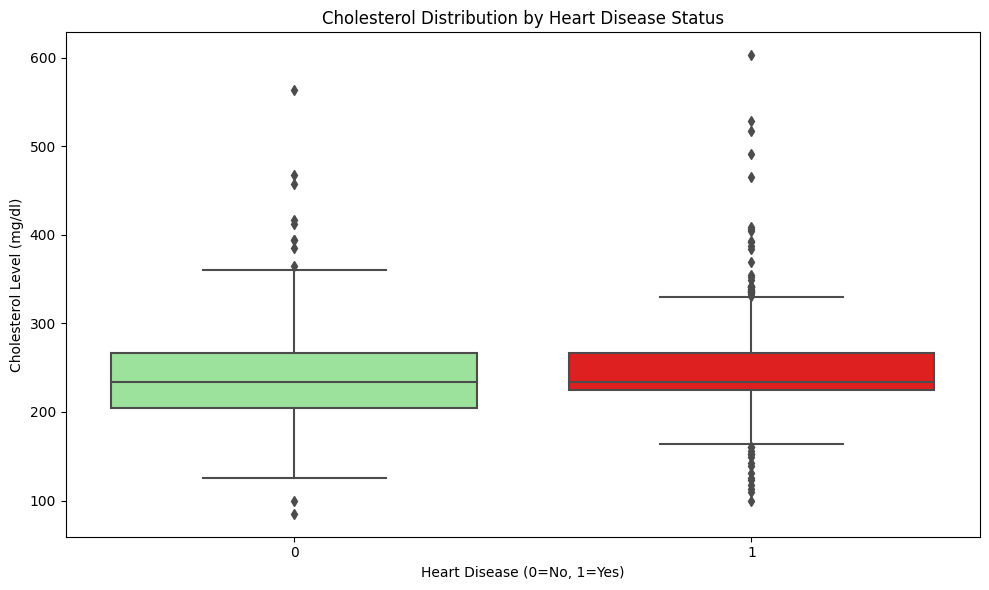

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df_clean, palette=['lightgreen', 'red'])
plt.title('Cholesterol Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Cholesterol Level (mg/dl)')
plt.tight_layout()
plt.show()

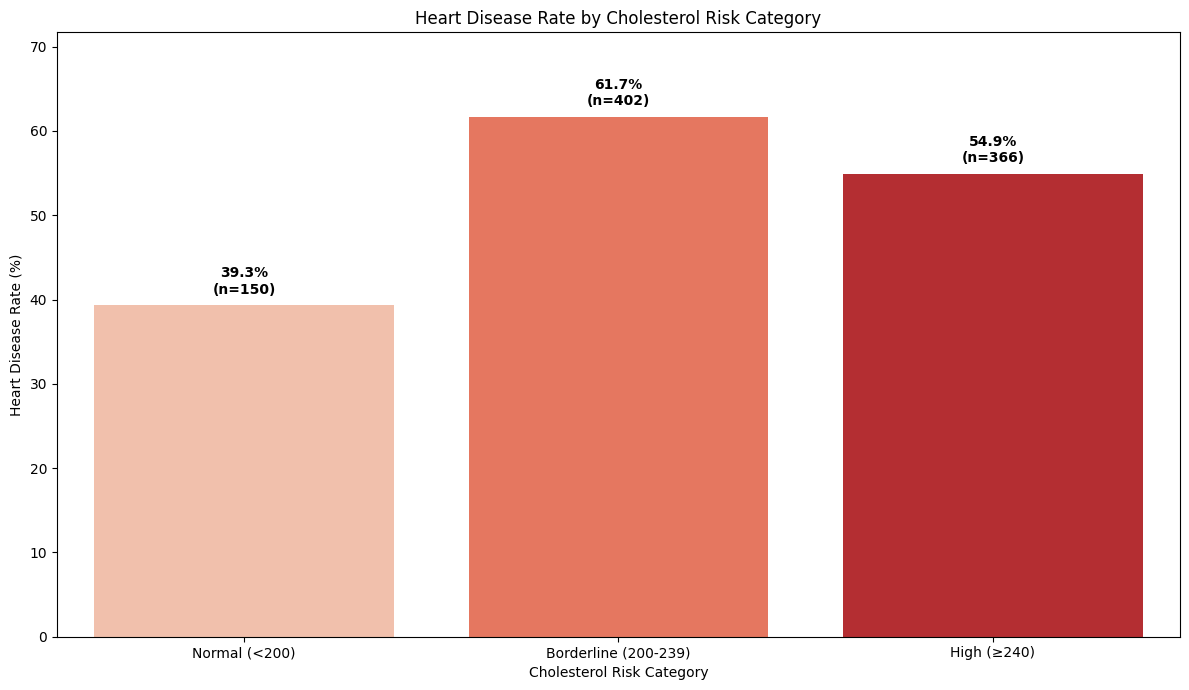

In [25]:
# Create cholesterol risk categories based on medical guidelines
df_clean['Cholesterol_Risk'] = pd.cut(df_clean['Cholesterol'],
                                    bins=[0, 200, 240, 1000],
                                    labels=['Normal (<200)', 'Borderline (200-239)', 'High (≥240)'])

# Calculate heart disease rate by cholesterol risk category
chol_risk_disease = df_clean.groupby('Cholesterol_Risk')['HeartDisease'].agg(['mean', 'count']).reset_index()
chol_risk_disease['Disease_Rate'] = chol_risk_disease['mean'] * 100

# Bar plot of heart disease rate by cholesterol risk category
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Cholesterol_Risk', y='Disease_Rate', data=chol_risk_disease, palette='Reds')
plt.title('Heart Disease Rate by Cholesterol Risk Category')
plt.xlabel('Cholesterol Risk Category')
plt.ylabel('Heart Disease Rate (%)')

for i, p in enumerate(ax.patches):
    count = chol_risk_disease.iloc[i]['count']
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, max(chol_risk_disease['Disease_Rate']) + 10)
plt.tight_layout()
plt.show()

### 2.2 Chest Pain Type vs Heart Disease Analysis

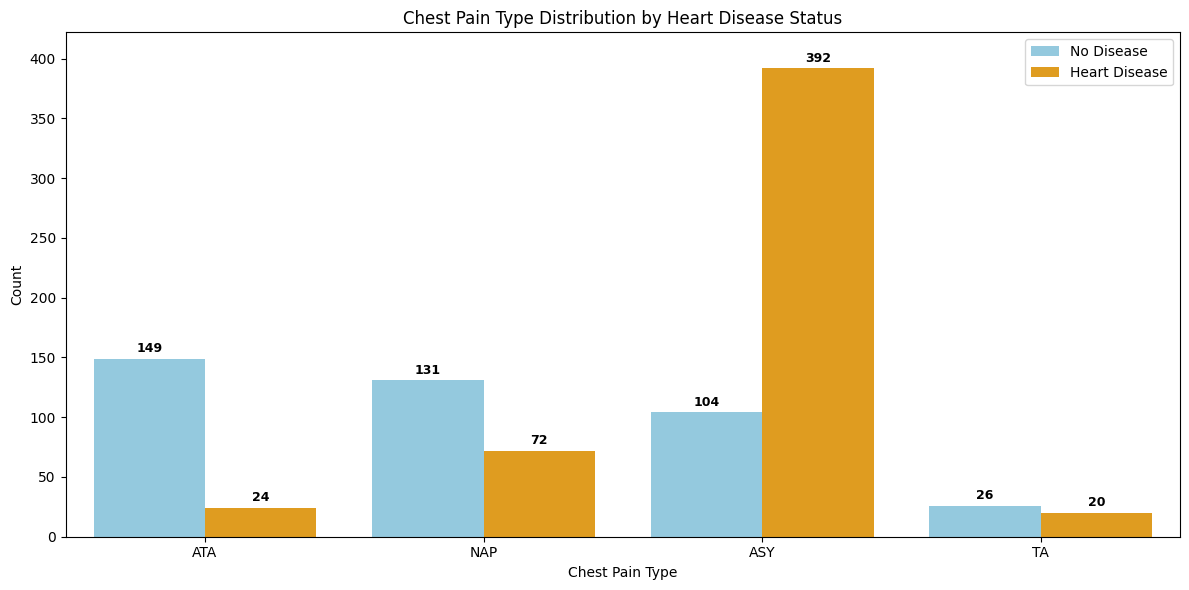

In [26]:
# Count plot of chest pain types by heart disease status
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_clean, x='ChestPainType', hue='HeartDisease', palette=['skyblue', 'orange'])
plt.title('Chest Pain Type Distribution by Heart Disease Status')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(['No Disease', 'Heart Disease'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 3),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.ylim(0, max([p.get_height() for p in ax.patches]) + 30)
plt.tight_layout()
plt.show()


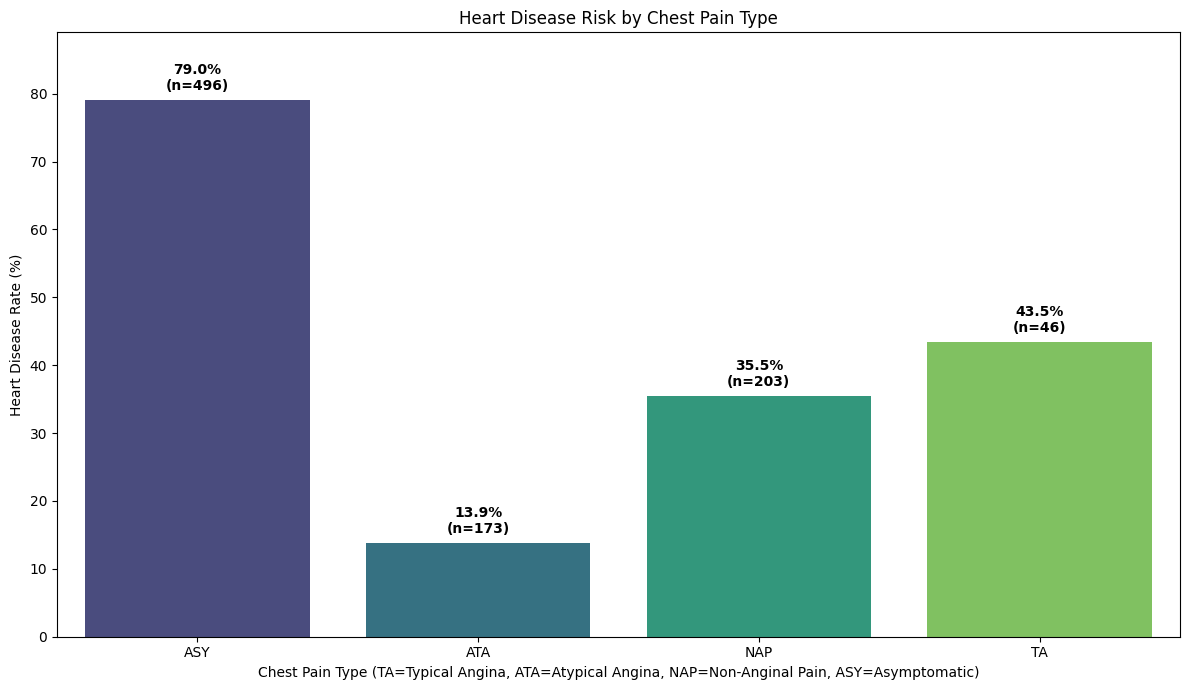

In [27]:
# Calculate heart disease rate by chest pain type
chest_pain_stats = df_clean.groupby('ChestPainType')['HeartDisease'].agg(['mean', 'count']).reset_index()
chest_pain_stats['Disease_Rate'] = chest_pain_stats['mean'] * 100

# Heart disease rate by chest pain type
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='ChestPainType', y='Disease_Rate', data=chest_pain_stats, palette='viridis')
plt.title('Heart Disease Risk by Chest Pain Type')
plt.xlabel('Chest Pain Type (TA=Typical Angina, ATA=Atypical Angina, NAP=Non-Anginal Pain, ASY=Asymptomatic)')
plt.ylabel('Heart Disease Rate (%)')

for i, p in enumerate(ax.patches):
    count = chest_pain_stats.iloc[i]['count']
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, max(chest_pain_stats['Disease_Rate']) + 10)
plt.tight_layout()
plt.show()


### 2.3 Blood Pressure Risk Assessment

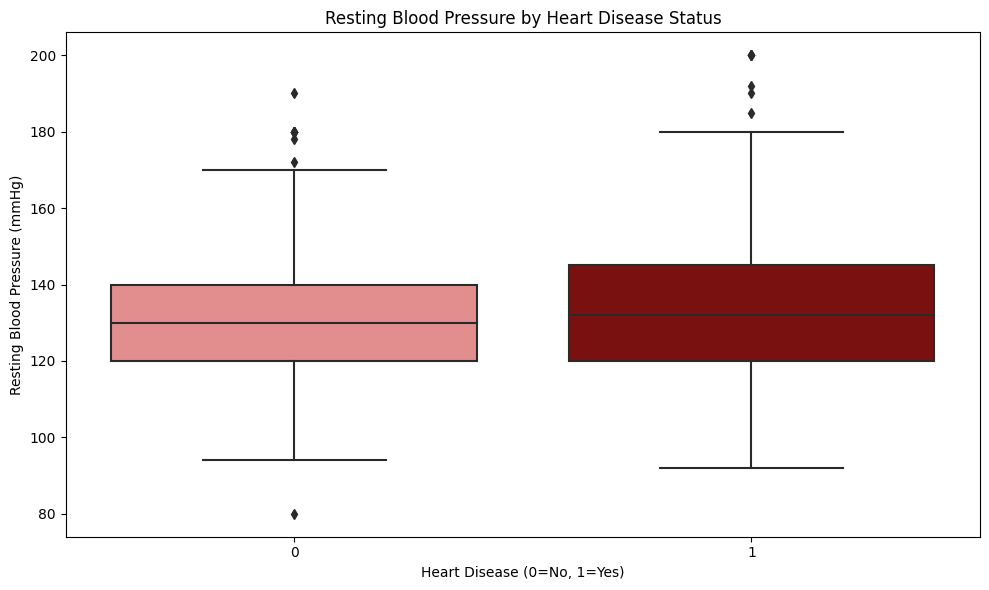

In [28]:
# Create blood pressure categories based on medical guidelines
df_clean['BP_Category'] = pd.cut(df_clean['RestingBP'],
                               bins=[0, 120, 140, 1000],
                               labels=['Normal (<120)', 'Elevated (120-139)', 'High (≥140)'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='HeartDisease', y='RestingBP', data=df_clean, palette=['lightcoral', 'darkred'])
plt.title('Resting Blood Pressure by Heart Disease Status')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Resting Blood Pressure (mmHg)')
plt.tight_layout()
plt.show()

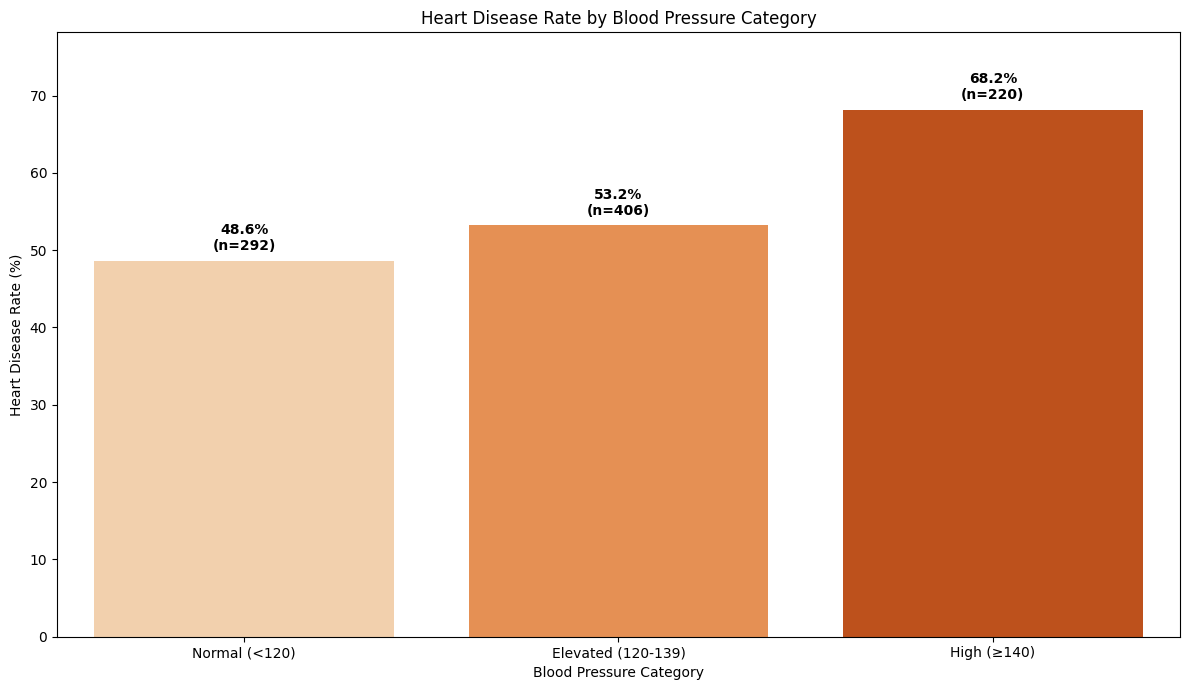

In [29]:
# Heart disease rate by blood pressure category
bp_disease_stats = df_clean.groupby('BP_Category')['HeartDisease'].agg(['mean', 'count']).reset_index()
bp_disease_stats['Disease_Rate'] = bp_disease_stats['mean'] * 100

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='BP_Category', y='Disease_Rate', data=bp_disease_stats, palette='Oranges')
plt.title('Heart Disease Rate by Blood Pressure Category')
plt.xlabel('Blood Pressure Category')
plt.ylabel('Heart Disease Rate (%)')

for i, p in enumerate(ax.patches):
    count = bp_disease_stats.iloc[i]['count']
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, max(bp_disease_stats['Disease_Rate']) + 10)
plt.tight_layout()
plt.show()

### 2.4 Gender-Based Cardiovascular Risk Analysis

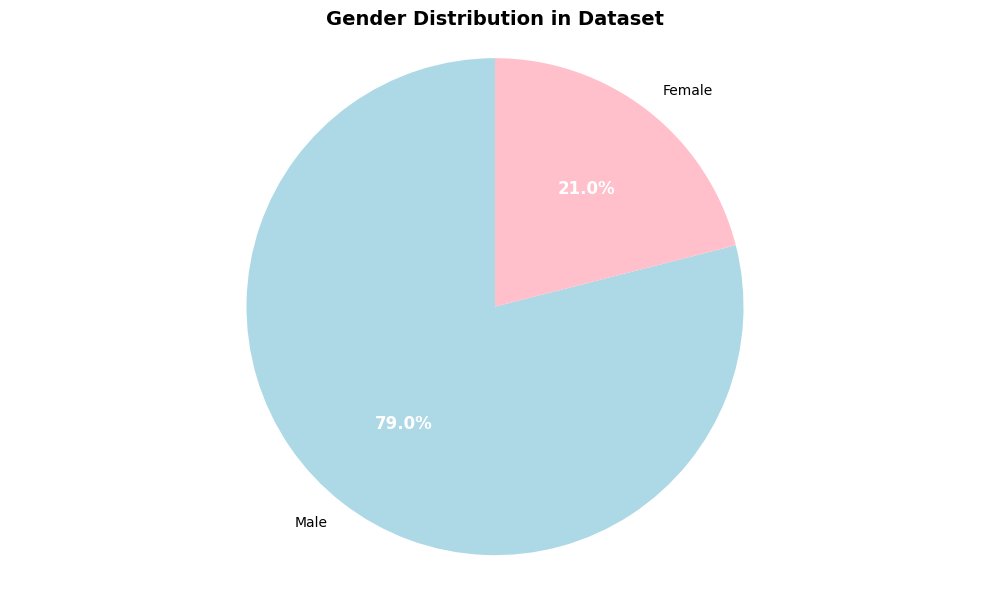

In [30]:
# Gender distribution in dataset
plt.figure(figsize=(10, 6))
gender_counts = df_clean['Sex'].value_counts()
colors = ['lightblue', 'pink']
wedges, texts, autotexts = plt.pie(gender_counts.values, labels=['Male', 'Female'], autopct='%1.1f%%',
                                  colors=colors, startangle=90)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

plt.title('Gender Distribution in Dataset', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

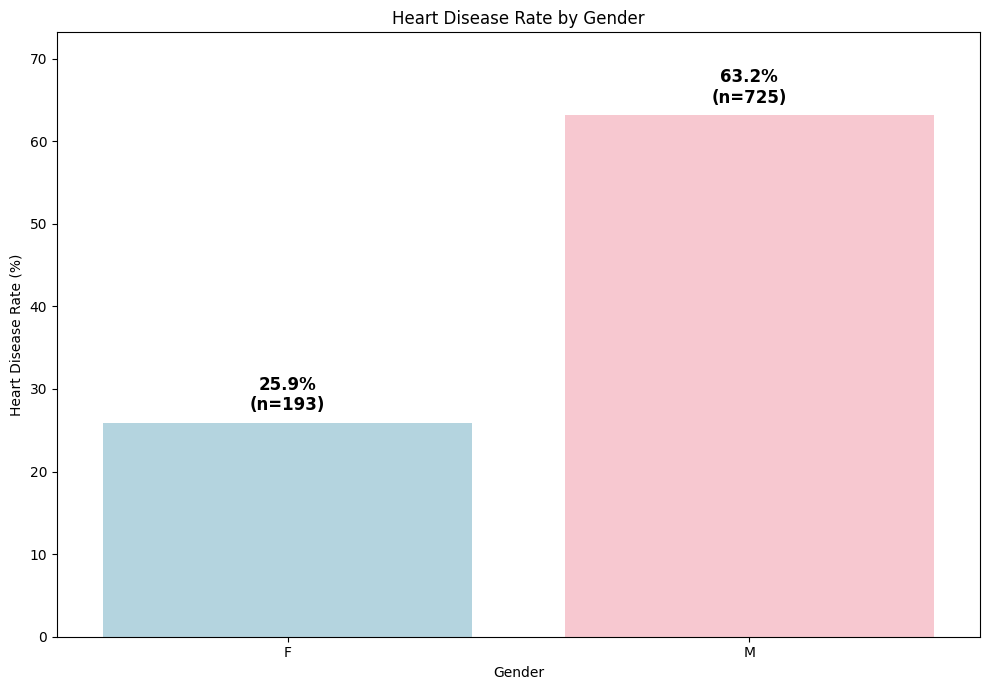

In [31]:
# Heart disease rate by gender
gender_disease_stats = df_clean.groupby('Sex')['HeartDisease'].agg(['mean', 'count']).reset_index()
gender_disease_stats['Disease_Rate'] = gender_disease_stats['mean'] * 100

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Sex', y='Disease_Rate', data=gender_disease_stats, palette=['lightblue', 'pink'])
plt.title('Heart Disease Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Heart Disease Rate (%)')

for i, p in enumerate(ax.patches):
    count = gender_disease_stats.iloc[i]['count']
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(gender_disease_stats['Disease_Rate']) + 10)
plt.tight_layout()
plt.show()

### 2.5 Diabetes Risk Factor Analysis

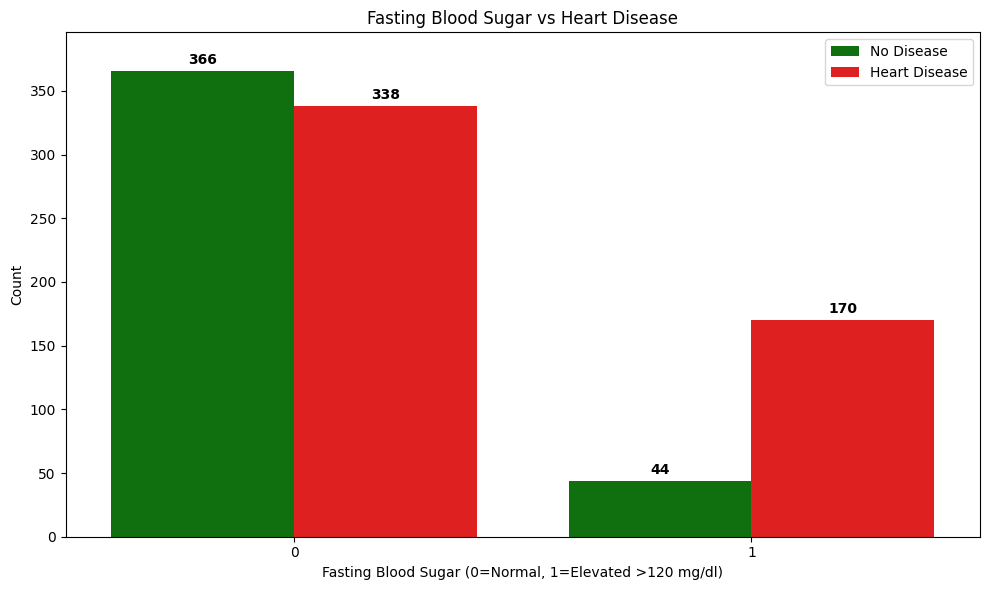

In [32]:
# Fasting blood sugar impact on heart disease
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_clean, x='FastingBS', hue='HeartDisease', palette=['green', 'red'])
plt.title('Fasting Blood Sugar vs Heart Disease')
plt.xlabel('Fasting Blood Sugar (0=Normal, 1=Elevated >120 mg/dl)')
plt.ylabel('Count')
plt.legend(['No Disease', 'Heart Disease'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 3),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, max([p.get_height() for p in ax.patches]) + 30)
plt.tight_layout()
plt.show()


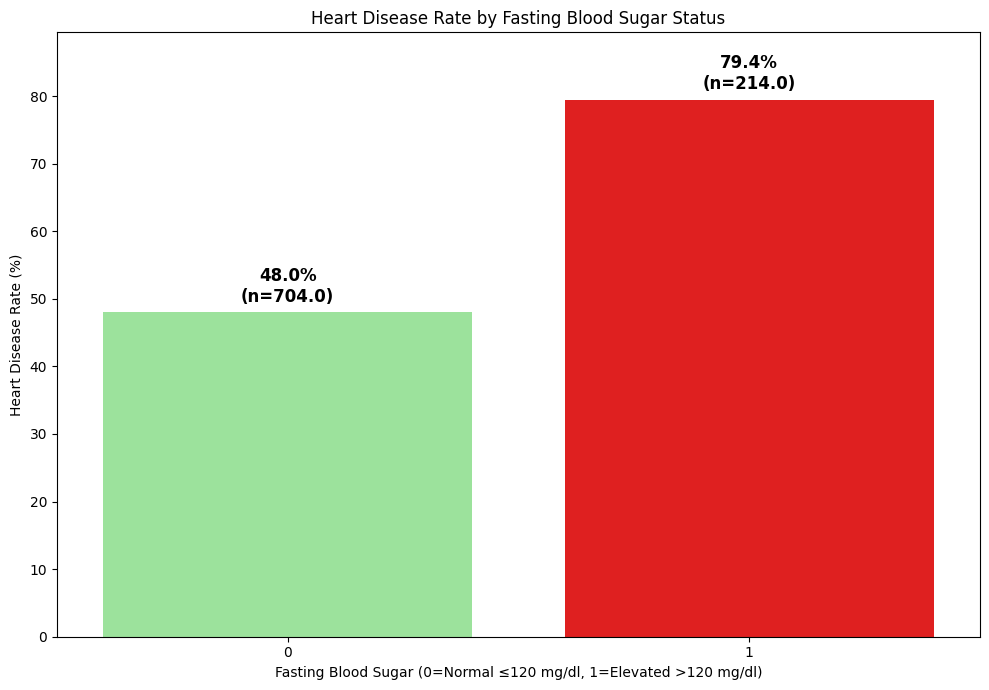

In [33]:
# Diabetes risk analysis
diabetes_stats = df_clean.groupby('FastingBS')['HeartDisease'].agg(['mean', 'count']).reset_index()
diabetes_stats['Disease_Rate'] = diabetes_stats['mean'] * 100

plt.figure(figsize=(10, 7))
ax = sns.barplot(x='FastingBS', y='Disease_Rate', data=diabetes_stats, palette=['lightgreen', 'red'])
plt.title('Heart Disease Rate by Fasting Blood Sugar Status')
plt.xlabel('Fasting Blood Sugar (0=Normal ≤120 mg/dl, 1=Elevated >120 mg/dl)')
plt.ylabel('Heart Disease Rate (%)')

for i, p in enumerate(ax.patches):
    count = diabetes_stats.iloc[i]['count']
    ax.annotate(f'{p.get_height():.1f}%\n(n={count})',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(diabetes_stats['Disease_Rate']) + 10)
plt.tight_layout()
plt.show()

## 3.0 Anomaly Detection

In [34]:
# Check for outliers in key numerical features using IQR method
for feature in ['Oldpeak', 'MaxHR', 'Age']:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)]
    print(f"{feature} outliers: {len(outliers)} records ({len(outliers)/len(df_clean)*100:.1f}%)")

# Check unusual patterns
print(f"\nUnusual patterns:")
young_with_disease = df_clean[(df_clean['Age'] < 40) & (df_clean['HeartDisease'] == 1)]
print(f"- Young patients (<40) with heart disease: {len(young_with_disease)} cases")

high_hr_with_disease = df_clean[(df_clean['MaxHR'] > 180) & (df_clean['HeartDisease'] == 1)]
print(f"- High MaxHR (>180) with heart disease: {len(high_hr_with_disease)} cases")

Oldpeak outliers: 16 records (1.7%)
MaxHR outliers: 2 records (0.2%)
Age outliers: 0 records (0.0%)

Unusual patterns:
- Young patients (<40) with heart disease: 26 cases
- High MaxHR (>180) with heart disease: 4 cases


In [35]:
df_clean

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,Sex_Male,ExerciseAngina_Yes,ST_Slope_Encoded,ChestPain_ATA,ChestPain_NAP,ChestPain_TA,ECG_Normal,ECG_ST,Cholesterol_Risk,BP_Category
0,40,M,ATA,140,289,0,Normal,172,N,0.0,...,1,0,2,True,False,False,True,False,High (≥240),Elevated (120-139)
1,49,F,NAP,160,180,0,Normal,156,N,1.0,...,0,0,1,False,True,False,True,False,Normal (<200),High (≥140)
2,37,M,ATA,130,283,0,ST,98,N,0.0,...,1,0,2,True,False,False,False,True,High (≥240),Elevated (120-139)
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,...,0,1,1,False,False,False,True,False,Borderline (200-239),Elevated (120-139)
4,54,M,NAP,150,195,0,Normal,122,N,0.0,...,1,0,2,False,True,False,True,False,Normal (<200),High (≥140)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,...,1,0,1,False,False,True,True,False,High (≥240),Normal (<120)
914,68,M,ASY,144,193,1,Normal,141,N,3.4,...,1,0,1,False,False,False,True,False,Normal (<200),High (≥140)
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,...,1,1,1,False,False,False,True,False,Normal (<200),Elevated (120-139)
916,57,F,ATA,130,236,0,LVH,174,N,0.0,...,0,0,1,True,False,False,False,False,Borderline (200-239),Elevated (120-139)


## 4.0 Model Development

In [36]:
# Prepare features and target
X = df_modeling.drop(target, axis=1)
y = df_modeling[target]

In [37]:
# Verify X contains only numeric data
print(f"Feature matrix shape: {X.shape}")
print(f"Feature data types:\n{X.dtypes}")
print(f"Target variable type: {y.dtype}")

Feature matrix shape: (918, 14)
Feature data types:
Age                     int64
RestingBP               int64
Cholesterol             int64
MaxHR                   int64
Oldpeak               float64
Sex_Male                int64
ExerciseAngina_Yes      int64
ST_Slope_Encoded        int64
FastingBS               int64
ChestPain_ATA            bool
ChestPain_NAP            bool
ChestPain_TA             bool
ECG_Normal               bool
ECG_ST                   bool
dtype: object
Target variable type: int64


In [38]:
# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Target distribution in train: {y_train.value_counts().to_dict()}")
print(f"Target distribution in test: {y_test.value_counts().to_dict()}")


Train set shape: (734, 14)
Test set shape: (184, 14)
Target distribution in train: {1: 406, 0: 328}
Target distribution in test: {1: 102, 0: 82}


In [39]:
# Verify no missing values in splits
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")

Missing values in X_train: 0
Missing values in X_test: 0


### 4.1 Logistic Regression with Parameter Tuning and Cross-Validation

In [40]:
# Parameter tuning for Logistic Regression
lr_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__class_weight': [None, 'balanced']
}

lr_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', LogisticRegression(max_iter=300, random_state=42))
])

# Grid search with cross-validation
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

lr_grid_search.fit(X_train, y_train)
lr_best_model = lr_grid_search.best_estimator_

print("Parameter Tuning Results:")
print(f"Best parameters: {lr_grid_search.best_params_}")
print(f"Best CV ROC AUC: {lr_grid_search.best_score_:.4f}")

Parameter Tuning Results:
Best parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV ROC AUC: 0.9116


In [41]:
# Cross-validation with best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_validate(
    lr_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'average_precision']
)

print("\n5-Fold Cross-Validation Results (Best Model):")
print(f"Accuracy: {lr_cv_scores['test_accuracy'].mean():.4f} (+/- {lr_cv_scores['test_accuracy'].std():.4f})")
print(f"ROC AUC: {lr_cv_scores['test_roc_auc'].mean():.4f} (+/- {lr_cv_scores['test_roc_auc'].std():.4f})")
print(f"Average Precision: {lr_cv_scores['test_average_precision'].mean():.4f} (+/- {lr_cv_scores['test_average_precision'].std():.4f})")


5-Fold Cross-Validation Results (Best Model):
Accuracy: 0.8406 (+/- 0.0244)
ROC AUC: 0.9154 (+/- 0.0360)
Average Precision: 0.9123 (+/- 0.0439)


### 4.2 Random Forest with Parameter Tuning and Cross-Validation

In [42]:
# Parameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 20],
    'min_samples_leaf': [1, 50],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced_subsample']
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

rf_grid_search.fit(X_train, y_train)
rf_best_model = rf_grid_search.best_estimator_

print("Parameter Tuning Results:")
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best CV ROC AUC: {rf_grid_search.best_score_:.4f}")

Parameter Tuning Results:
Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC AUC: 0.9233


In [43]:
# Cross-validation with best model
rf_cv_scores = cross_validate(
    rf_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'average_precision']
)

print("\n5-Fold Cross-Validation Results (Best Model):")
print(f"Accuracy: {rf_cv_scores['test_accuracy'].mean():.4f} (+/- {rf_cv_scores['test_accuracy'].std():.4f})")
print(f"ROC AUC: {rf_cv_scores['test_roc_auc'].mean():.4f} (+/- {rf_cv_scores['test_roc_auc'].std():.4f})")
print(f"Average Precision: {rf_cv_scores['test_average_precision'].mean():.4f} (+/- {rf_cv_scores['test_average_precision'].std():.4f})")


5-Fold Cross-Validation Results (Best Model):
Accuracy: 0.8556 (+/- 0.0373)
ROC AUC: 0.9224 (+/- 0.0252)
Average Precision: 0.9200 (+/- 0.0182)


### 4.3 XGBoost with Parameter Tuning and Cross-Validation

In [44]:
# Parameter tuning for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, len(y_train[y_train==0])/len(y_train[y_train==1])]
}

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

xgb_grid_search.fit(X_train, y_train)
xgb_best_model = xgb_grid_search.best_estimator_

print("Parameter Tuning Results:")
print(f"Best parameters: {xgb_grid_search.best_params_}")
print(f"Best CV ROC AUC: {xgb_grid_search.best_score_:.4f}")

Parameter Tuning Results:
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best CV ROC AUC: 0.9252


In [45]:
# Cross-validation with best model
xgb_cv_scores = cross_validate(
    xgb_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'average_precision']
)

print("\n5-Fold Cross-Validation Results (Best Model):")
print(f"Accuracy: {xgb_cv_scores['test_accuracy'].mean():.4f} (+/- {xgb_cv_scores['test_accuracy'].std():.4f})")
print(f"ROC AUC: {xgb_cv_scores['test_roc_auc'].mean():.4f} (+/- {xgb_cv_scores['test_roc_auc'].std():.4f})")
print(f"Average Precision: {xgb_cv_scores['test_average_precision'].mean():.4f} (+/- {xgb_cv_scores['test_average_precision'].std():.4f})")


5-Fold Cross-Validation Results (Best Model):
Accuracy: 0.8665 (+/- 0.0238)
ROC AUC: 0.9297 (+/- 0.0290)
Average Precision: 0.9324 (+/- 0.0302)


### 4.4 Support Vector Machine with Parameter Tuning and Cross-Validation


In [46]:
# Parameter tuning for SVM
svm_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__class_weight': [None, 'balanced']
}

svm_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

svm_grid_search.fit(X_train, y_train)
svm_best_model = svm_grid_search.best_estimator_

print("Parameter Tuning Results:")
print(f"Best parameters: {svm_grid_search.best_params_}")
print(f"Best CV ROC AUC: {svm_grid_search.best_score_:.4f}")

Parameter Tuning Results:
Best parameters: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV ROC AUC: 0.9103


In [47]:
# Cross-validation with best model
svm_cv_scores = cross_validate(
    svm_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'average_precision']
)

print("\n5-Fold Cross-Validation Results (Best Model):")
print(f"Accuracy: {svm_cv_scores['test_accuracy'].mean():.4f} (+/- {svm_cv_scores['test_accuracy'].std():.4f})")
print(f"ROC AUC: {svm_cv_scores['test_roc_auc'].mean():.4f} (+/- {svm_cv_scores['test_roc_auc'].std():.4f})")
print(f"Average Precision: {svm_cv_scores['test_average_precision'].mean():.4f} (+/- {svm_cv_scores['test_average_precision'].std():.4f})")


5-Fold Cross-Validation Results (Best Model):
Accuracy: 0.8447 (+/- 0.0392)
ROC AUC: 0.9120 (+/- 0.0339)
Average Precision: 0.9220 (+/- 0.0321)


### 4.5 Naive Bayes with Parameter Tuning and Cross-Validation

In [48]:
# Parameter tuning for Naive Bayes (limited parameters)
nb_param_grid = {
    'classifier__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

nb_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', GaussianNB())
])

nb_grid_search = GridSearchCV(
    nb_pipeline,
    nb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

nb_grid_search.fit(X_train, y_train)
nb_best_model = nb_grid_search.best_estimator_

print("Parameter Tuning Results:")
print(f"Best parameters: {nb_grid_search.best_params_}")
print(f"Best CV ROC AUC: {nb_grid_search.best_score_:.4f}")

Parameter Tuning Results:
Best parameters: {'classifier__var_smoothing': 1e-10}
Best CV ROC AUC: 0.8995


In [49]:
# Cross-validation with best model
nb_cv_scores = cross_validate(
    nb_best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'average_precision']
)

print("\n5-Fold Cross-Validation Results (Best Model):")
print(f"Accuracy: {nb_cv_scores['test_accuracy'].mean():.4f} (+/- {nb_cv_scores['test_accuracy'].std():.4f})")
print(f"ROC AUC: {nb_cv_scores['test_roc_auc'].mean():.4f} (+/- {nb_cv_scores['test_roc_auc'].std():.4f})")
print(f"Average Precision: {nb_cv_scores['test_average_precision'].mean():.4f} (+/- {nb_cv_scores['test_average_precision'].std():.4f})")


5-Fold Cross-Validation Results (Best Model):
Accuracy: 0.8338 (+/- 0.0312)
ROC AUC: 0.9012 (+/- 0.0428)
Average Precision: 0.9053 (+/- 0.0462)


## 5.0 Model Evaluation

### 5.1 Logistic Regression Evaluation

In [50]:
# Train and evaluate best model
lr_best_model.fit(X_train, y_train)
lr_test_pred = lr_best_model.predict(X_test)
lr_test_pred_proba = lr_best_model.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, lr_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_test_pred_proba):.4f}")
print("\nClassification Report - Test Set:")
print(classification_report(y_test, lr_test_pred))


Test Performance:
Accuracy Score: 0.8587
ROC AUC Score: 0.9035

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        82
           1       0.87      0.88      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



### 5.2 Random Forest Evaluation

In [51]:
# Train and evaluate best model
rf_best_model.fit(X_train, y_train)
rf_test_pred = rf_best_model.predict(X_test)
rf_test_pred_proba = rf_best_model.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, rf_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_test_pred_proba):.4f}")
print("\nClassification Report - Test Set:")
print(classification_report(y_test, rf_test_pred))


Test Performance:
Accuracy Score: 0.8641
ROC AUC Score: 0.9311

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        82
           1       0.88      0.87      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



### 5.3 XGBoost Evaluation

In [52]:
# Train and evaluate best model
xgb_best_model.fit(X_train, y_train)
xgb_test_pred = xgb_best_model.predict(X_test)
xgb_test_pred_proba = xgb_best_model.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, xgb_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, xgb_test_pred_proba):.4f}")
print("\nClassification Report - Test Set:")
print(classification_report(y_test, xgb_test_pred))


Test Performance:
Accuracy Score: 0.8804
ROC AUC Score: 0.9313

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



### 5.4 Support Vector Machine Evaluation

In [53]:
# Train and evaluate best model
svm_best_model.fit(X_train, y_train)
svm_test_pred = svm_best_model.predict(X_test)
svm_test_pred_proba = svm_best_model.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, svm_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, svm_test_pred_proba):.4f}")
print("\nClassification Report - Test Set:")
print(classification_report(y_test, svm_test_pred))


Test Performance:
Accuracy Score: 0.8641
ROC AUC Score: 0.9311

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84        82
           1       0.86      0.90      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



### 5.5 Naive Bayes Evaluation

In [54]:
# Train and evaluate best model
nb_best_model.fit(X_train, y_train)
nb_test_pred = nb_best_model.predict(X_test)
nb_test_pred_proba = nb_best_model.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(f"Accuracy Score: {accuracy_score(y_test, nb_test_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, nb_test_pred_proba):.4f}")
print("\nClassification Report - Test Set:")
print(classification_report(y_test, nb_test_pred))



Test Performance:
Accuracy Score: 0.8641
ROC AUC Score: 0.9244

Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



## 6.0 Confusion Matrix and ROC Curve Analysis

### 6.1 Logistic Regression Confusion Matrix & ROC curve

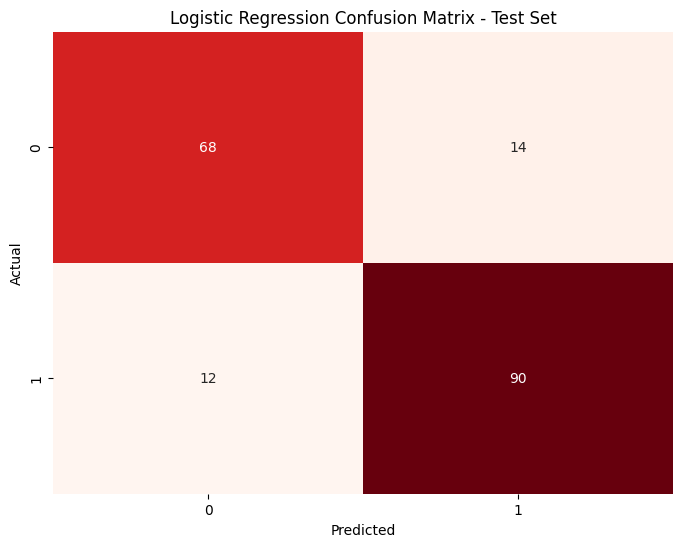

In [55]:
# Logistic Regression confusion matrix - Test set
plt.figure(figsize=(8, 6))
cm_test = confusion_matrix(y_test, lr_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Logistic Regression Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

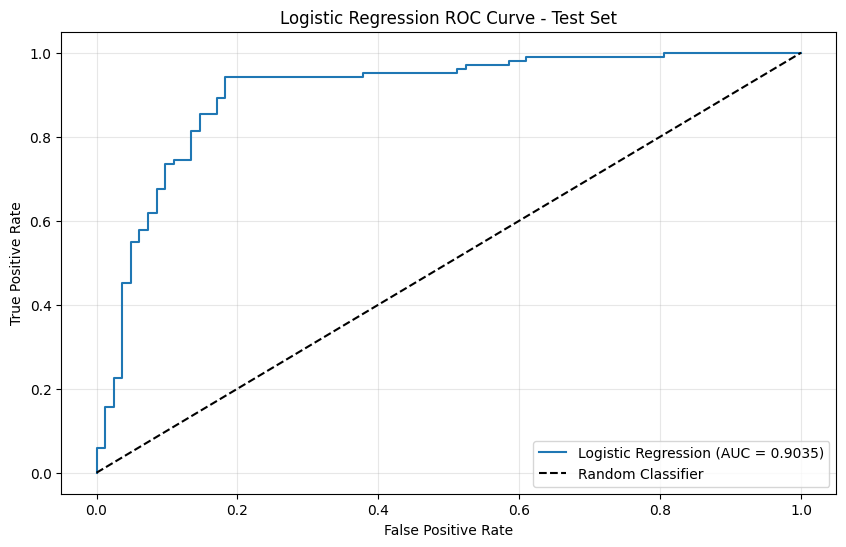

In [56]:
# ROC curve plot for Logistic Regression - Test set
plt.figure(figsize=(10, 6))
fpr_lr_test, tpr_lr_test, _ = roc_curve(y_test, lr_test_pred_proba)
plt.plot(fpr_lr_test, tpr_lr_test, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_test_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### 6.2 Random Forest Confusion Matrix & ROC curve

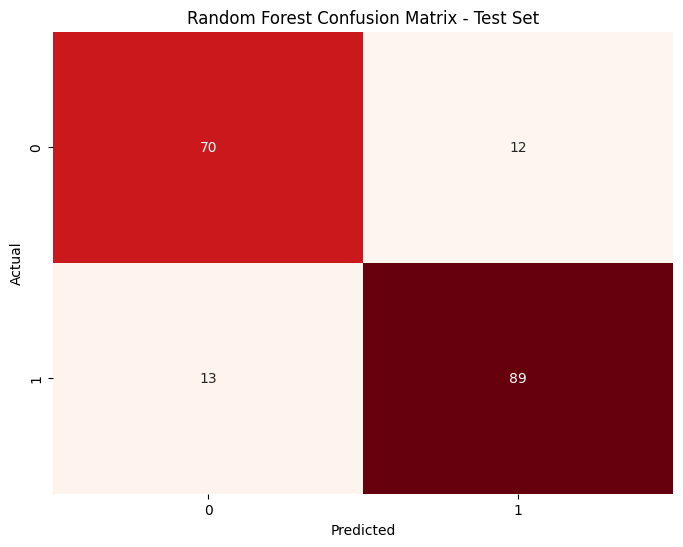

In [57]:
# Random Forest confusion matrix - Test set
plt.figure(figsize=(8, 6))
cm_rf_test = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Random Forest Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

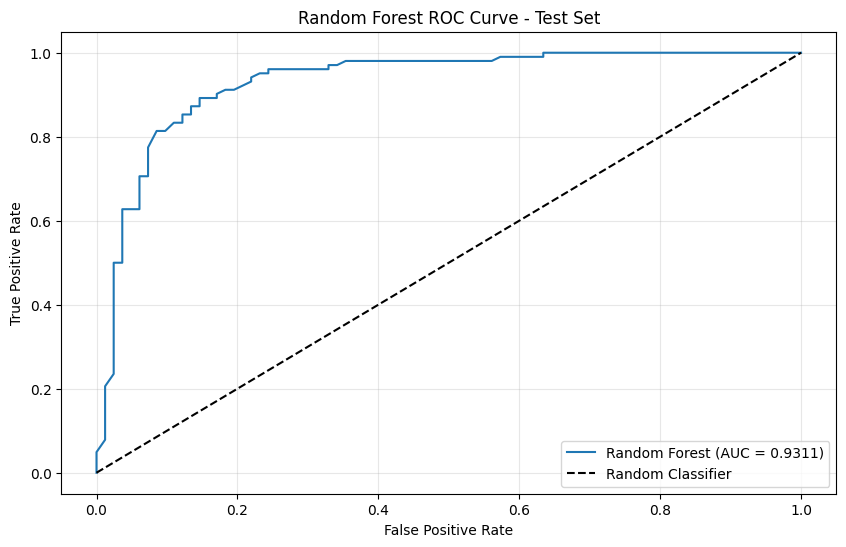

In [58]:
# ROC curve plot for Random Forest - Test set
plt.figure(figsize=(10, 6))
fpr_rf_test, tpr_rf_test, _ = roc_curve(y_test, rf_test_pred_proba)
plt.plot(fpr_rf_test, tpr_rf_test, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_test_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### 6.3 XGBoost Confusion Matrix & ROC curve

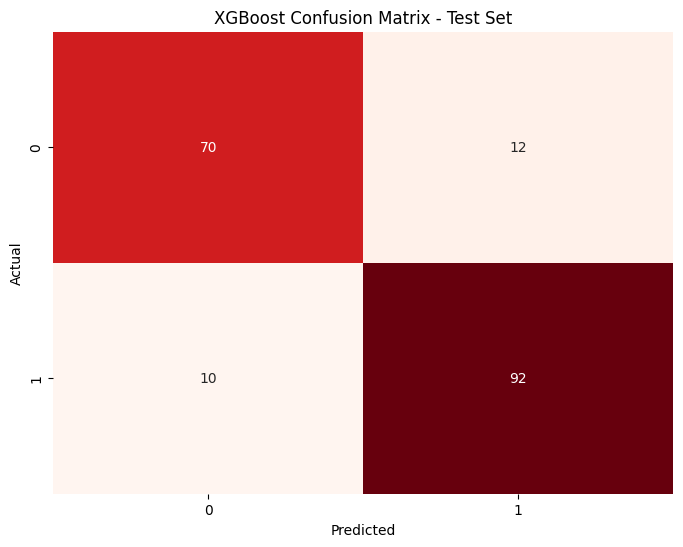

In [59]:
# XGBoost confusion matrix - Test set
plt.figure(figsize=(8, 6))
cm_xgb_test = confusion_matrix(y_test, xgb_test_pred)
sns.heatmap(cm_xgb_test, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('XGBoost Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

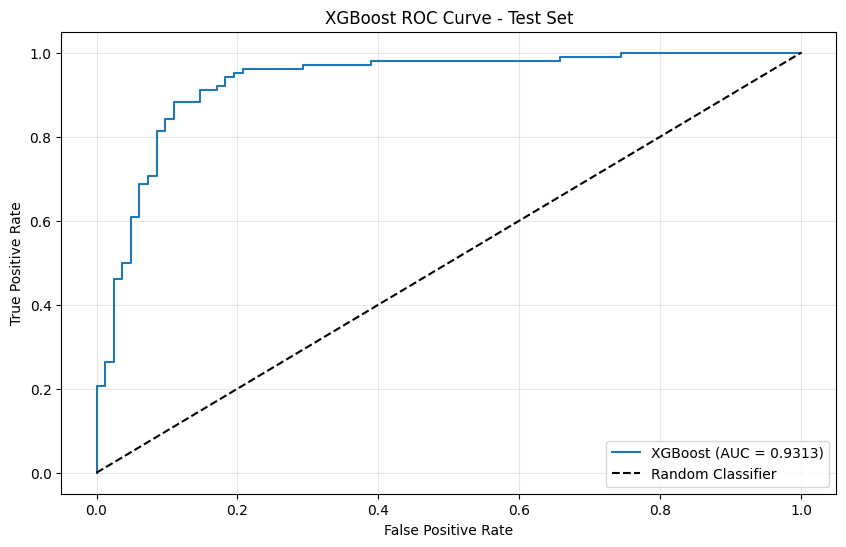

In [60]:
# ROC curve plot for XGBoost - Test set
plt.figure(figsize=(10, 6))
fpr_xgb_test, tpr_xgb_test, _ = roc_curve(y_test, xgb_test_pred_proba)
plt.plot(fpr_xgb_test, tpr_xgb_test, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_test_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### 6.4 Support Vector Machine Confusion Matrix & ROC curve

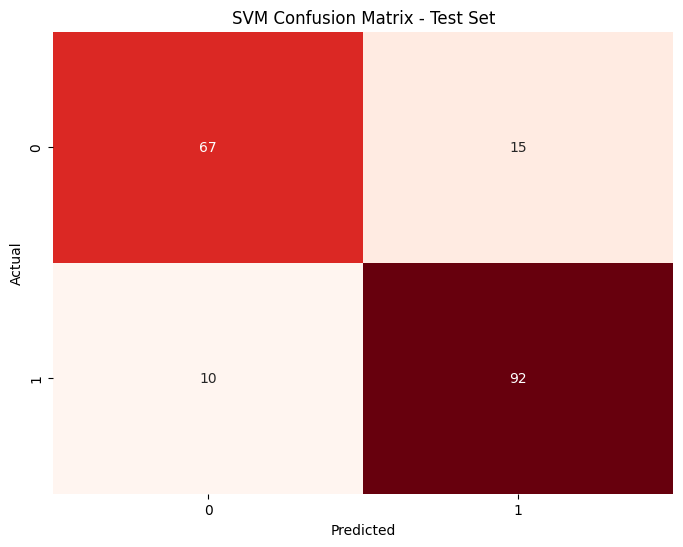

In [61]:
# SVM confusion matrix - Test set
plt.figure(figsize=(8, 6))
cm_svm_test = confusion_matrix(y_test, svm_test_pred)
sns.heatmap(cm_svm_test, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('SVM Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

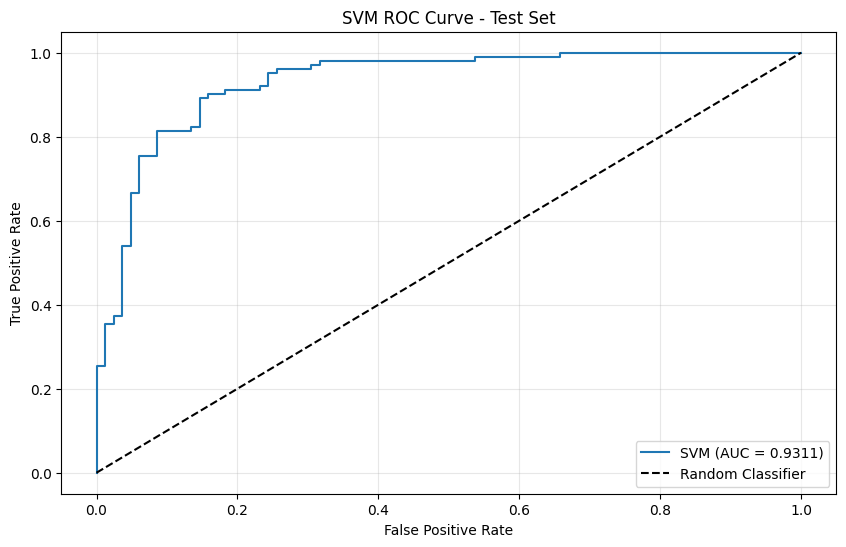

In [62]:
# ROC curve plot for SVM - Test set
plt.figure(figsize=(10, 6))
fpr_svm_test, tpr_svm_test, _ = roc_curve(y_test, svm_test_pred_proba)
plt.plot(fpr_svm_test, tpr_svm_test, label=f'SVM (AUC = {roc_auc_score(y_test, svm_test_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### 6.5 Naive Bayes Confusion Matrix & ROC curve

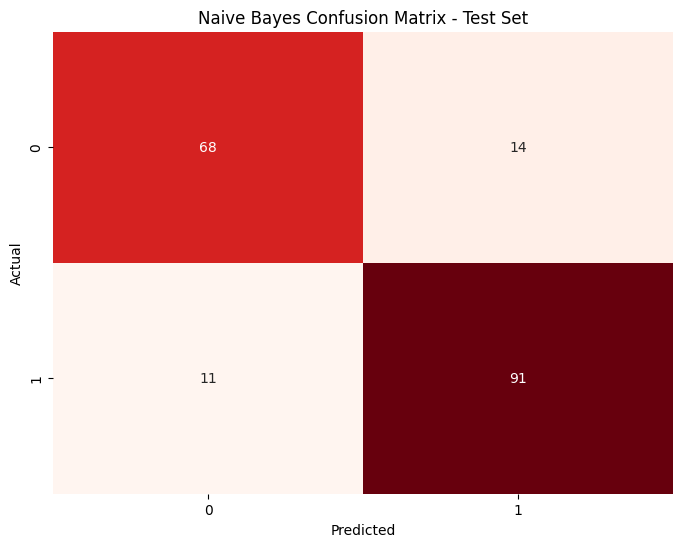

In [63]:
# Naive Bayes confusion matrix - Test set
plt.figure(figsize=(8, 6))
cm_nb_test = confusion_matrix(y_test, nb_test_pred)
sns.heatmap(cm_nb_test, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Naive Bayes Confusion Matrix - Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

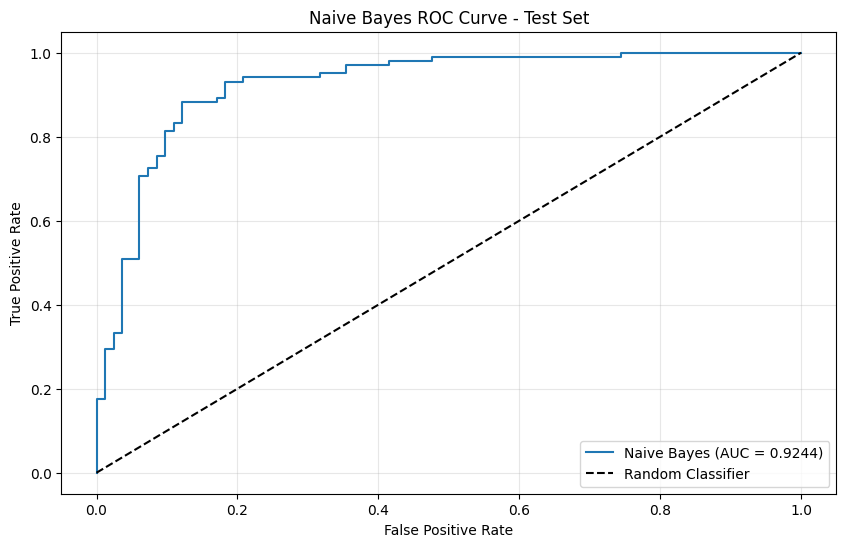

In [64]:
# ROC curve plot for Naive Bayes - Test set
plt.figure(figsize=(10, 6))
fpr_nb_test, tpr_nb_test, _ = roc_curve(y_test, nb_test_pred_proba)
plt.plot(fpr_nb_test, tpr_nb_test, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, nb_test_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 7.0 Comprehensive Model Performance Comparison

### 7.1 Evaluation Metrics Analysis

In [65]:
# This dictionary to store all model results
model_results = {
    'Logistic Regression': {
        'predictions': lr_test_pred,
        'probabilities': lr_test_pred_proba,
        'cv_scores': lr_cv_scores
    },
    'Random Forest': {
        'predictions': rf_test_pred,
        'probabilities': rf_test_pred_proba,
        'cv_scores': rf_cv_scores
    },
    'XGBoost': {
        'predictions': xgb_test_pred,
        'probabilities': xgb_test_pred_proba,
        'cv_scores': xgb_cv_scores
    },
    'SVM': {
        'predictions': svm_test_pred,
        'probabilities': svm_test_pred_proba,
        'cv_scores': svm_cv_scores
    },
    'Naive Bayes': {
        'predictions': nb_test_pred,
        'probabilities': nb_test_pred_proba,
        'cv_scores': nb_cv_scores
    }
}

def calculate_comprehensive_metrics(y_true, y_pred, y_prob):
    """Calculate all relevant metrics for a model"""

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    negative_predictive_value = tn / (tn + fn) if (tn + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0


    sensitivity = recall
    positive_predictive_value = precision

    return {
        'Accuracy': accuracy,
        'Precision (PPV)': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC AUC': roc_auc,
        'NPV': negative_predictive_value,
        'FPR': false_positive_rate,
        'FNR': false_negative_rate,
        'True Positives': tp,
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn
    }

# This calculate metrics for all models
comprehensive_metrics = {}
for model_name, results in model_results.items():
    print(f"Calculating metrics for {model_name}...")
    metrics = calculate_comprehensive_metrics(
        y_test,
        results['predictions'],
        results['probabilities']
    )
    comprehensive_metrics[model_name] = metrics

Calculating metrics for Logistic Regression...
Calculating metrics for Random Forest...
Calculating metrics for XGBoost...
Calculating metrics for SVM...
Calculating metrics for Naive Bayes...


In [66]:
# This can convert to DataFrame for easy comparison
metrics_df = pd.DataFrame(comprehensive_metrics).T
metrics_df = metrics_df.round(4)

In [67]:
print("COMPREHENSIVE EVALUATION METRICS COMPARISON:")
print("="*120)
print(metrics_df[['Accuracy', 'Precision (PPV)', 'Recall (Sensitivity)', 'Specificity', 'F1-Score', 'ROC AUC']].to_string())

COMPREHENSIVE EVALUATION METRICS COMPARISON:
                     Accuracy  Precision (PPV)  Recall (Sensitivity)  Specificity  F1-Score  ROC AUC
Logistic Regression    0.8587           0.8654                0.8824       0.8293    0.8738   0.9035
Random Forest          0.8641           0.8812                0.8725       0.8537    0.8768   0.9311
XGBoost                0.8804           0.8846                0.9020       0.8537    0.8932   0.9313
SVM                    0.8641           0.8598                0.9020       0.8171    0.8804   0.9311
Naive Bayes            0.8641           0.8667                0.8922       0.8293    0.8792   0.9244


In [68]:
confusion_summary = metrics_df[['True Positives', 'False Positives', 'True Negatives', 'False Negatives']]
print("CONFUSION MATRIX COMPONENTS:")
print("="*90)
print(confusion_summary.to_string())

CONFUSION MATRIX COMPONENTS:
                     True Positives  False Positives  True Negatives  False Negatives
Logistic Regression            90.0             14.0            68.0             12.0
Random Forest                  89.0             12.0            70.0             13.0
XGBoost                        92.0             12.0            70.0             10.0
SVM                            92.0             15.0            67.0             10.0
Naive Bayes                    91.0             14.0            68.0             11.0


### 7.2 Model Performance Summary Table

In [69]:
# Collect all cross-validation results (from tuned models)
models_cv_results = {
    'Logistic Regression': lr_cv_scores,
    'Random Forest': rf_cv_scores,
    'XGBoost': xgb_cv_scores,
    'SVM': svm_cv_scores,
    'Naive Bayes': nb_cv_scores
}

# Collect all test results (from tuned models)
models_test_results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, lr_test_pred),
        'roc_auc': roc_auc_score(y_test, lr_test_pred_proba),
        'avg_precision': average_precision_score(y_test, lr_test_pred_proba),
        'predictions': lr_test_pred,
        'probabilities': lr_test_pred_proba,
        'best_params': lr_grid_search.best_params_
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_test, rf_test_pred),
        'roc_auc': roc_auc_score(y_test, rf_test_pred_proba),
        'avg_precision': average_precision_score(y_test, rf_test_pred_proba),
        'predictions': rf_test_pred,
        'probabilities': rf_test_pred_proba,
        'best_params': rf_grid_search.best_params_
    },
    'XGBoost': {
        'accuracy': accuracy_score(y_test, xgb_test_pred),
        'roc_auc': roc_auc_score(y_test, xgb_test_pred_proba),
        'avg_precision': average_precision_score(y_test, xgb_test_pred_proba),
        'predictions': xgb_test_pred,
        'probabilities': xgb_test_pred_proba,
        'best_params': xgb_grid_search.best_params_
    },
    'SVM': {
        'accuracy': accuracy_score(y_test, svm_test_pred),
        'roc_auc': roc_auc_score(y_test, svm_test_pred_proba),
        'avg_precision': average_precision_score(y_test, svm_test_pred_proba),
        'predictions': svm_test_pred,
        'probabilities': svm_test_pred_proba,
        'best_params': svm_grid_search.best_params_
    },
    'Naive Bayes': {
        'accuracy': accuracy_score(y_test, nb_test_pred),
        'roc_auc': roc_auc_score(y_test, nb_test_pred_proba),
        'avg_precision': average_precision_score(y_test, nb_test_pred_proba),
        'predictions': nb_test_pred,
        'probabilities': nb_test_pred_proba,
        'best_params': nb_grid_search.best_params_
    }
}

# I create comprehensive comparison table
comparison_data = []
for name in models_cv_results.keys():
    cv_scores = models_cv_results[name]
    test_results = models_test_results[name]

    comparison_data.append({
        'Model': name,
        'CV_Accuracy_Mean': cv_scores['test_accuracy'].mean(),
        'CV_Accuracy_Std': cv_scores['test_accuracy'].std(),
        'CV_ROC_AUC_Mean': cv_scores['test_roc_auc'].mean(),
        'CV_ROC_AUC_Std': cv_scores['test_roc_auc'].std(),
        'CV_Avg_Precision_Mean': cv_scores['test_average_precision'].mean(),
        'CV_Avg_Precision_Std': cv_scores['test_average_precision'].std(),
        'Test_Accuracy': test_results['accuracy'],
        'Test_ROC_AUC': test_results['roc_auc'],
        'Test_Avg_Precision': test_results['avg_precision']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n=== COMPREHENSIVE MODEL PERFORMANCE SUMMARY (TUNED MODELS) ===")
print(comparison_df.to_string(index=False))


=== COMPREHENSIVE MODEL PERFORMANCE SUMMARY (TUNED MODELS) ===
              Model  CV_Accuracy_Mean  CV_Accuracy_Std  CV_ROC_AUC_Mean  CV_ROC_AUC_Std  CV_Avg_Precision_Mean  CV_Avg_Precision_Std  Test_Accuracy  Test_ROC_AUC  Test_Avg_Precision
Logistic Regression            0.8406           0.0244           0.9154          0.0360                 0.9123                0.0439         0.8587        0.9035              0.8979
      Random Forest            0.8556           0.0373           0.9224          0.0252                 0.9200                0.0182         0.8641        0.9311              0.9242
            XGBoost            0.8665           0.0238           0.9297          0.0290                 0.9324                0.0302         0.8804        0.9313              0.9346
                SVM            0.8447           0.0392           0.9120          0.0339                 0.9220                0.0321         0.8641        0.9311              0.9370
        Naive Bayes       

### 7.3 Cross-Validation Accuracy Comparison

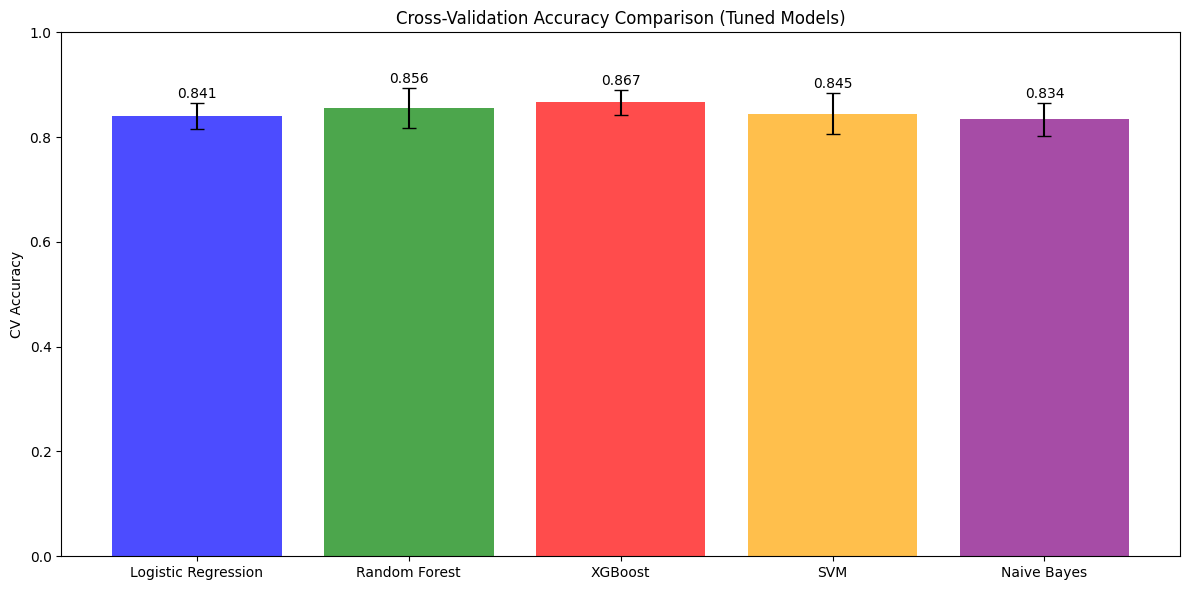

In [70]:
plt.figure(figsize=(12, 6))

models = list(models_cv_results.keys())
colors = ['blue', 'green', 'red', 'orange', 'purple']

# This is the CV Accuracy comparison to see which model has the highest accuracy
cv_accuracy_means = [comparison_df[comparison_df['Model'] == model]['CV_Accuracy_Mean'].iloc[0] for model in models]
cv_accuracy_stds = [comparison_df[comparison_df['Model'] == model]['CV_Accuracy_Std'].iloc[0] for model in models]

plt.bar(range(len(models)), cv_accuracy_means, yerr=cv_accuracy_stds,
        color=colors, alpha=0.7, capsize=5)
plt.title('Cross-Validation Accuracy Comparison (Tuned Models)')
plt.ylabel('CV Accuracy')
plt.xticks(range(len(models)), models)
plt.ylim(0, 1)
for i, (mean, std) in enumerate(zip(cv_accuracy_means, cv_accuracy_stds)):
    plt.text(i, mean + std + 0.01, f'{mean:.3f}', ha='center')

plt.tight_layout()
plt.show()

### 7.4 Cross-Validation ROC AUC Comparison

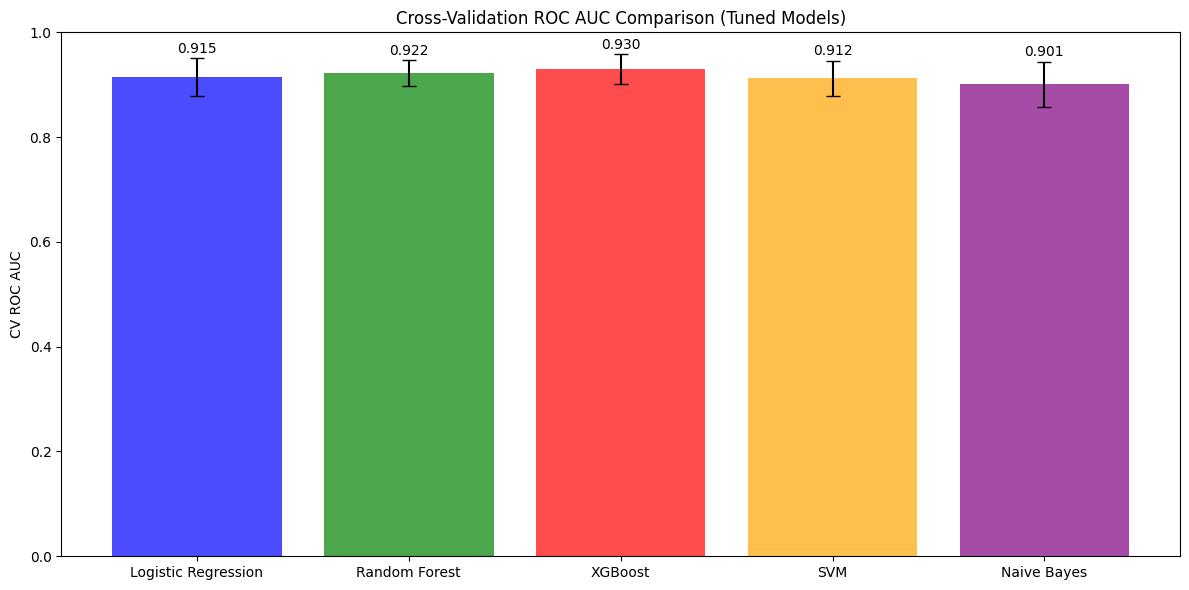

In [71]:
plt.figure(figsize=(12, 6))

# I created a CV ROC AUC comparison to see which model has the highestCV ROC AUC
cv_auc_means = [comparison_df[comparison_df['Model'] == model]['CV_ROC_AUC_Mean'].iloc[0] for model in models]
cv_auc_stds = [comparison_df[comparison_df['Model'] == model]['CV_ROC_AUC_Std'].iloc[0] for model in models]

plt.bar(range(len(models)), cv_auc_means, yerr=cv_auc_stds,
        color=colors, alpha=0.7, capsize=5)
plt.title('Cross-Validation ROC AUC Comparison (Tuned Models)')
plt.ylabel('CV ROC AUC')
plt.xticks(range(len(models)), models)
plt.ylim(0, 1)
for i, (mean, std) in enumerate(zip(cv_auc_means, cv_auc_stds)):
    plt.text(i, mean + std + 0.01, f'{mean:.3f}', ha='center')

plt.tight_layout()
plt.show()

### 7.5 Test Set Performance Comparison

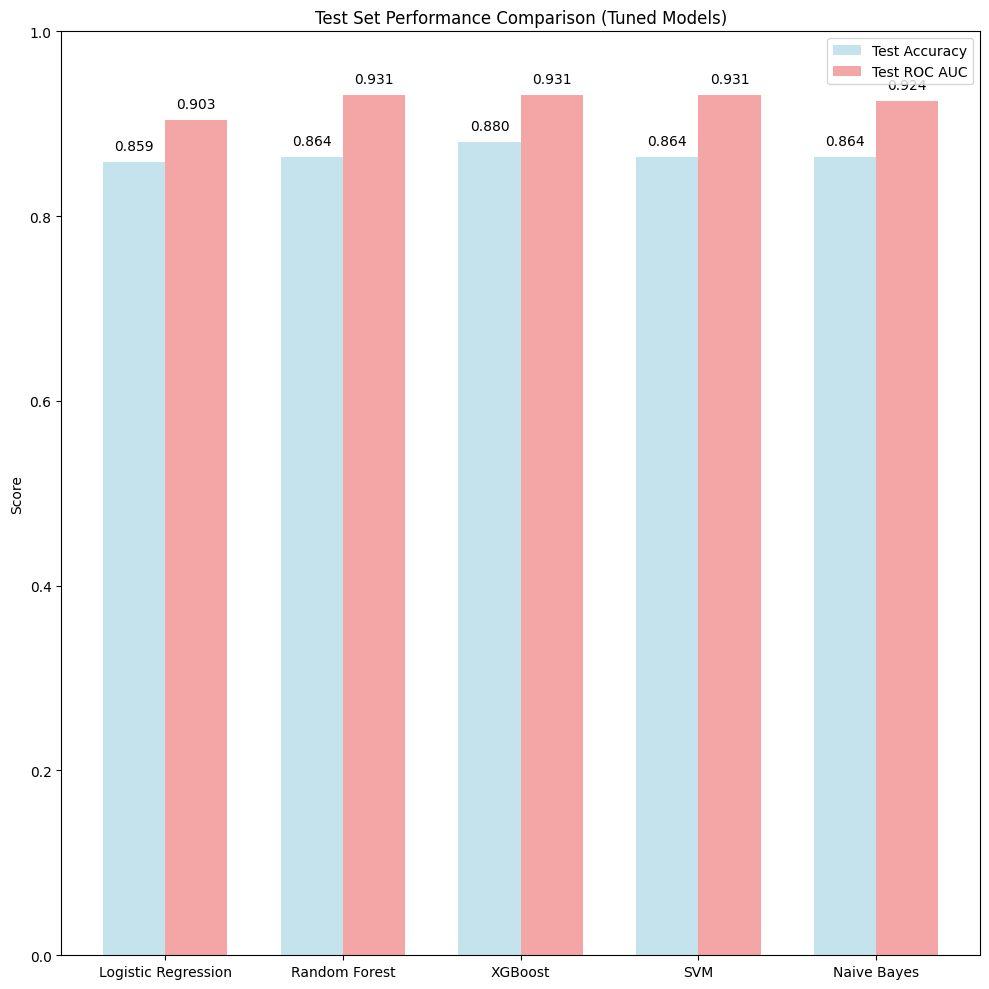

In [72]:
plt.figure(figsize=(10, 10))

test_accuracy = [comparison_df[comparison_df['Model'] == model]['Test_Accuracy'].iloc[0] for model in models]
test_auc = [comparison_df[comparison_df['Model'] == model]['Test_ROC_AUC'].iloc[0] for model in models]

x_pos = np.arange(len(models))
width = 0.35

plt.bar(x_pos - width/2, test_accuracy, width, label='Test Accuracy', color='lightblue', alpha=0.7)
plt.bar(x_pos + width/2, test_auc, width, label='Test ROC AUC', color='lightcoral', alpha=0.7)

for i, (acc, auc) in enumerate(zip(test_accuracy, test_auc)):
    plt.text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')
    plt.text(i + width/2, auc + 0.01, f'{auc:.3f}', ha='center', va='bottom')

plt.title('Test Set Performance Comparison (Tuned Models)')
plt.ylabel('Score')
plt.xticks(x_pos, models)
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

### 7.6 All Models ROC Curves Comparison

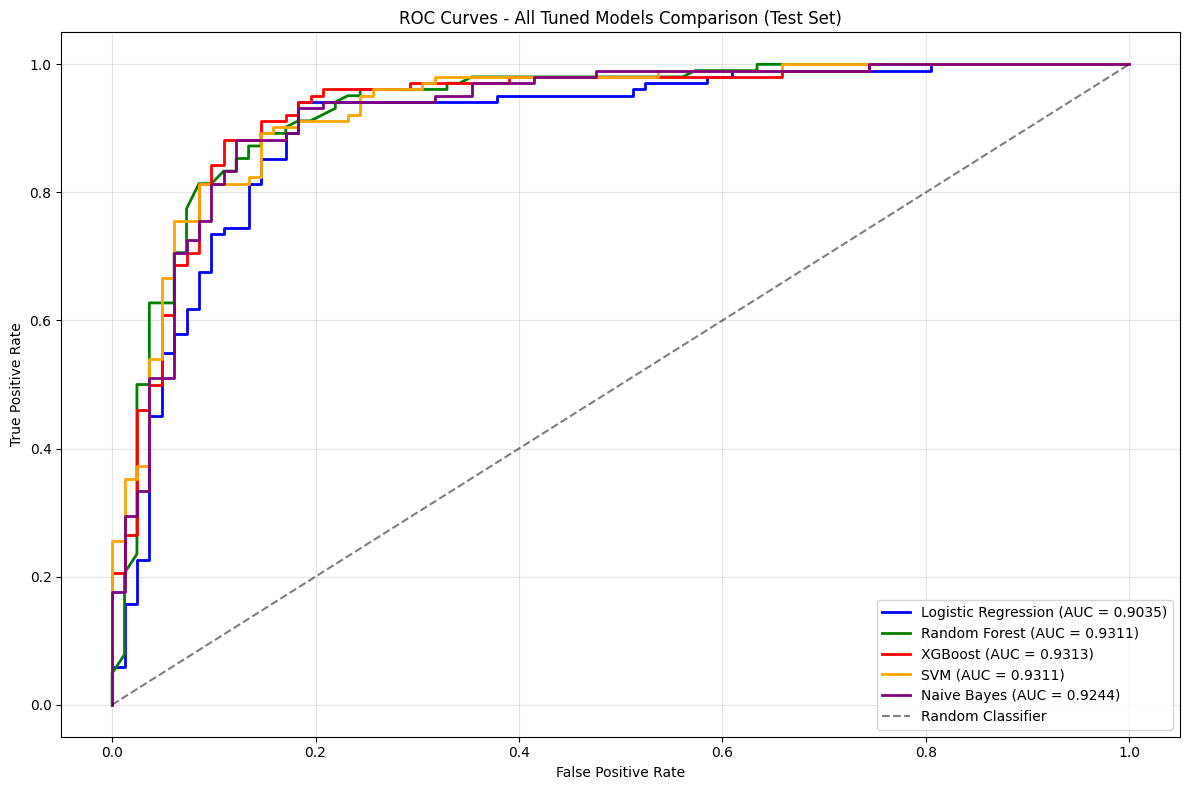

In [73]:
# All models ROC curves comparison
plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'red', 'orange', 'purple']

for i, (name, results) in enumerate(models_test_results.items()):
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {results["roc_auc"]:.4f})',
             color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Tuned Models Comparison (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8.0 Bonus: Advanced Ensemble Techniques Implementation

### 8.1 Voting Classifier Ensemble

In [74]:
# I have created base estimators using my best models
base_estimators = [
    ('logistic_regression', lr_best_model),
    ('random_forest', rf_best_model),
    ('xgboost', xgb_best_model),
    ('svm', svm_best_model),
    ('naive_bayes', nb_best_model)
]

# This is Hard Voting Classifier
hard_voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting='hard'
)

print("Training Hard Voting Classifier...")
hard_voting_clf.fit(X_train, y_train)

Training Hard Voting Classifier...


VotingClassifier(estimators=[('logistic_regression',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               LogisticRegression(C=1,
                                                                  class_weight='balanced',
                                                                  max_iter=300,
                                                                  penalty='l1',
                                                                  random_state=42,
                                                                  solver='liblinear'))])),
                             ('random_forest',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgboost'...
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('svm',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               SVC(C=10, gamma='auto',
                                                   probability=True,
                                                   random_state=42))])),
                             ('naive_bayes',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               GaussianNB(var_smoothing=1e-10))]))])

In [75]:
# This is Soft Voting Classifier (uses probabilities)
soft_voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)

print("Training Soft Voting Classifier...")
soft_voting_clf.fit(X_train, y_train)

Training Soft Voting Classifier...


VotingClassifier(estimators=[('logistic_regression',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               LogisticRegression(C=1,
                                                                  class_weight='balanced',
                                                                  max_iter=300,
                                                                  penalty='l1',
                                                                  random_state=42,
                                                                  solver='liblinear'))])),
                             ('random_forest',
                              RandomForestClassifier(class_weight='balanced_subsample',
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgboost'...
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('svm',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               SVC(C=10, gamma='auto',
                                                   probability=True,
                                                   random_state=42))])),
                             ('naive_bayes',
                              Pipeline(steps=[('scaler', RobustScaler()),
                                              ('classifier',
                                               GaussianNB(var_smoothing=1e-10))]))],
                 voting='soft')

In [76]:
# Evaluate both voting methods
hard_pred = hard_voting_clf.predict(X_test)

soft_pred = soft_voting_clf.predict(X_test)
soft_pred_proba = soft_voting_clf.predict_proba(X_test)[:, 1]

In [77]:
# So, for hard voting, calculate ROC AUC using original individual model probabilities
def get_hard_voting_probabilities_simple(X):
    """Get probability estimates by averaging individual best model probabilities"""
    individual_probas = []

    models = [lr_best_model, rf_best_model, xgb_best_model, svm_best_model, nb_best_model]
    model_names = ['logistic_regression', 'random_forest', 'xgboost', 'svm', 'naive_bayes']

    for i, model in enumerate(models):
        try:
            proba = model.predict_proba(X)[:, 1]
            individual_probas.append(proba)
        except Exception as e:
            print(f"Warning: Could not get probabilities from {model_names[i]}: {e}")
            continue

    if len(individual_probas) == 0:
        return np.full(len(X), 0.5)

    avg_proba = np.mean(individual_probas, axis=0)
    return avg_proba

hard_pred_proba = get_hard_voting_probabilities_simple(X_test)

print(f"\nHard Voting Results:")
print(f"  Accuracy: {accuracy_score(y_test, hard_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, hard_pred_proba):.4f}")




Hard Voting Results:
  Accuracy: 0.8750
  ROC AUC: 0.9371


In [78]:
print(f"\nSoft Voting Results:")
print(f"  Accuracy: {accuracy_score(y_test, soft_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, soft_pred_proba):.4f}")


Soft Voting Results:
  Accuracy: 0.8859
  ROC AUC: 0.9371


### 8.2 Weighted Ensemble Based on CV Performance

In [79]:
# This is to extract CV performance for weighting
cv_performance = {
    'logistic_regression': lr_cv_scores['test_roc_auc'].mean(),
    'random_forest': rf_cv_scores['test_roc_auc'].mean(),
    'xgboost': xgb_cv_scores['test_roc_auc'].mean(),
    'svm': svm_cv_scores['test_roc_auc'].mean(),
    'naive_bayes': nb_cv_scores['test_roc_auc'].mean()
}

print("CV Performance for Weighting:")
for model, score in cv_performance.items():
    print(f"  {model}: {score:.4f}")

CV Performance for Weighting:
  logistic_regression: 0.9154
  random_forest: 0.9224
  xgboost: 0.9297
  svm: 0.9120
  naive_bayes: 0.9012


In [80]:
# This calculate weights based on performance (softmax-like)
total_performance = sum(cv_performance.values())
weights = {model: score/total_performance for model, score in cv_performance.items()}

print(f"\nCalculated Weights:")
for model, weight in weights.items():
    print(f"  {model}: {weight:.3f}")


Calculated Weights:
  logistic_regression: 0.200
  random_forest: 0.201
  xgboost: 0.203
  svm: 0.199
  naive_bayes: 0.197


In [81]:
# I customize the weighted ensemble prediction
def weighted_ensemble_predict(models, X, weights):
    """Custom weighted ensemble prediction"""
    predictions = []
    model_names = ['logistic_regression', 'random_forest', 'xgboost', 'svm', 'naive_bayes']

    for i, (name, model) in enumerate(zip(model_names, models)):
        pred_proba = model.predict_proba(X)[:, 1]
        weighted_pred = pred_proba * weights[name]
        predictions.append(weighted_pred)

    ensemble_proba = np.sum(predictions, axis=0)
    ensemble_pred = (ensemble_proba > 0.5).astype(int)

    return ensemble_pred, ensemble_proba

# Then I apply weighted ensemble
models_list = [lr_best_model, rf_best_model, xgb_best_model, svm_best_model, nb_best_model]
weighted_pred, weighted_pred_proba = weighted_ensemble_predict(models_list, X_test, weights)

print(f"\nWeighted Ensemble Results:")
print(f"  Accuracy: {accuracy_score(y_test, weighted_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, weighted_pred_proba):.4f}")


Weighted Ensemble Results:
  Accuracy: 0.8859
  ROC AUC: 0.9375


### 8.3 Stacking Classifier (Meta-learner)

In [82]:
# Create base learners (exclude one for meta-learner)
base_learners = [
    ('random_forest', rf_best_model),
    ('xgboost', xgb_best_model),
    ('svm', svm_best_model),
    ('naive_bayes', nb_best_model)
]

# Use Logistic Regression as meta-learner
meta_learner = LogisticRegression(random_state=42)

# Create Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)

print("Training Stacking Classifier...")
stacking_clf.fit(X_train, y_train)

Training Stacking Classifier...


StackingClassifier(cv=5,
                   estimators=[('random_forest',
                                RandomForestClassifier(class_weight='balanced_subsample',
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=Fa...
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('svm',
                                Pipeline(steps=[('scaler', RobustScaler()),
                                                ('classifier',
                                                 SVC(C=10, gamma='auto',
                                                     probability=True,
                                                     random_state=42))])),
                               ('naive_bayes',
                                Pipeline(steps=[('scaler', RobustScaler()),
                                                ('classifier',
                                                 GaussianNB(var_smoothing=1e-10))]))],
                   final_estimator=LogisticRegression(random_state=42))

In [83]:
# I evaluate stacking classifier
stacking_pred = stacking_clf.predict(X_test)
stacking_pred_proba = stacking_clf.predict_proba(X_test)[:, 1]

print(f"\nStacking Classifier Results:")
print(f"  Accuracy: {accuracy_score(y_test, stacking_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, stacking_pred_proba):.4f}")


Stacking Classifier Results:
  Accuracy: 0.8967
  ROC AUC: 0.9379


### 8.4 Advanced Clinical Ensemble (Domain-Specific)

In [84]:
# This is clinical weights based on interpretability and medical relevance
clinical_weights = {
    'logistic_regression': 0.30,
    'random_forest': 0.25,
    'xgboost': 0.25,
    'svm': 0.15,
    'naive_bayes': 0.05
}

print("Clinical Domain Weights:")
for model, weight in clinical_weights.items():
    print(f"  {model}: {weight:.2f}")

# I therefore apply clinical ensemble
clinical_pred, clinical_pred_proba = weighted_ensemble_predict(models_list, X_test, clinical_weights)

print(f"\nClinical Ensemble Results:")
print(f"  Accuracy: {accuracy_score(y_test, clinical_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, clinical_pred_proba):.4f}")

Clinical Domain Weights:
  logistic_regression: 0.30
  random_forest: 0.25
  xgboost: 0.25
  svm: 0.15
  naive_bayes: 0.05

Clinical Ensemble Results:
  Accuracy: 0.8804
  ROC AUC: 0.9338


## 9.0 Ensemble Performance Comparison

In [85]:
ensemble_results = {
    'Hard Voting': {
        'accuracy': accuracy_score(y_test, hard_pred),
        'roc_auc': roc_auc_score(y_test, hard_pred_proba),
        'predictions': hard_pred,
        'probabilities': hard_pred_proba
    },
    'Soft Voting': {
        'accuracy': accuracy_score(y_test, soft_pred),
        'roc_auc': roc_auc_score(y_test, soft_pred_proba),
        'predictions': soft_pred,
        'probabilities': soft_pred_proba
    },
    'Weighted Ensemble': {
        'accuracy': accuracy_score(y_test, weighted_pred),
        'roc_auc': roc_auc_score(y_test, weighted_pred_proba),
        'predictions': weighted_pred,
        'probabilities': weighted_pred_proba
    },
    'Stacking Classifier': {
        'accuracy': accuracy_score(y_test, stacking_pred),
        'roc_auc': roc_auc_score(y_test, stacking_pred_proba),
        'predictions': stacking_pred,
        'probabilities': stacking_pred_proba
    },
    'Clinical Ensemble': {
        'accuracy': accuracy_score(y_test, clinical_pred),
        'roc_auc': roc_auc_score(y_test, clinical_pred_proba),
        'predictions': clinical_pred,
        'probabilities': clinical_pred_proba
    }
}

# I have created comparison table to the comparison of the Ensemble Method's Accuracy and ROC AUC
comparison_data = []
for name, results in ensemble_results.items():
    comparison_data.append({
        'Ensemble Method': name,
        'Accuracy': results['accuracy'],
        'ROC AUC': results['roc_auc']
    })

ensemble_comparison_df = pd.DataFrame(comparison_data).round(4)
print("\nEnsemble Methods Performance Comparison:")
print(ensemble_comparison_df.to_string(index=False))


Ensemble Methods Performance Comparison:
    Ensemble Method  Accuracy  ROC AUC
        Hard Voting    0.8750   0.9371
        Soft Voting    0.8859   0.9371
  Weighted Ensemble    0.8859   0.9375
Stacking Classifier    0.8967   0.9379
  Clinical Ensemble    0.8804   0.9338


In [86]:
# Im trying to find best ensemble method
best_ensemble = max(ensemble_results.items(), key=lambda x: x[1]['roc_auc'])
print(f"\nBest Ensemble Method: {best_ensemble[0]}")
print(f"  Accuracy: {best_ensemble[1]['accuracy']:.4f}")
print(f"  ROC AUC: {best_ensemble[1]['roc_auc']:.4f}")


Best Ensemble Method: Stacking Classifier
  Accuracy: 0.8967
  ROC AUC: 0.9379


### 9.1 Ensemble Visualization

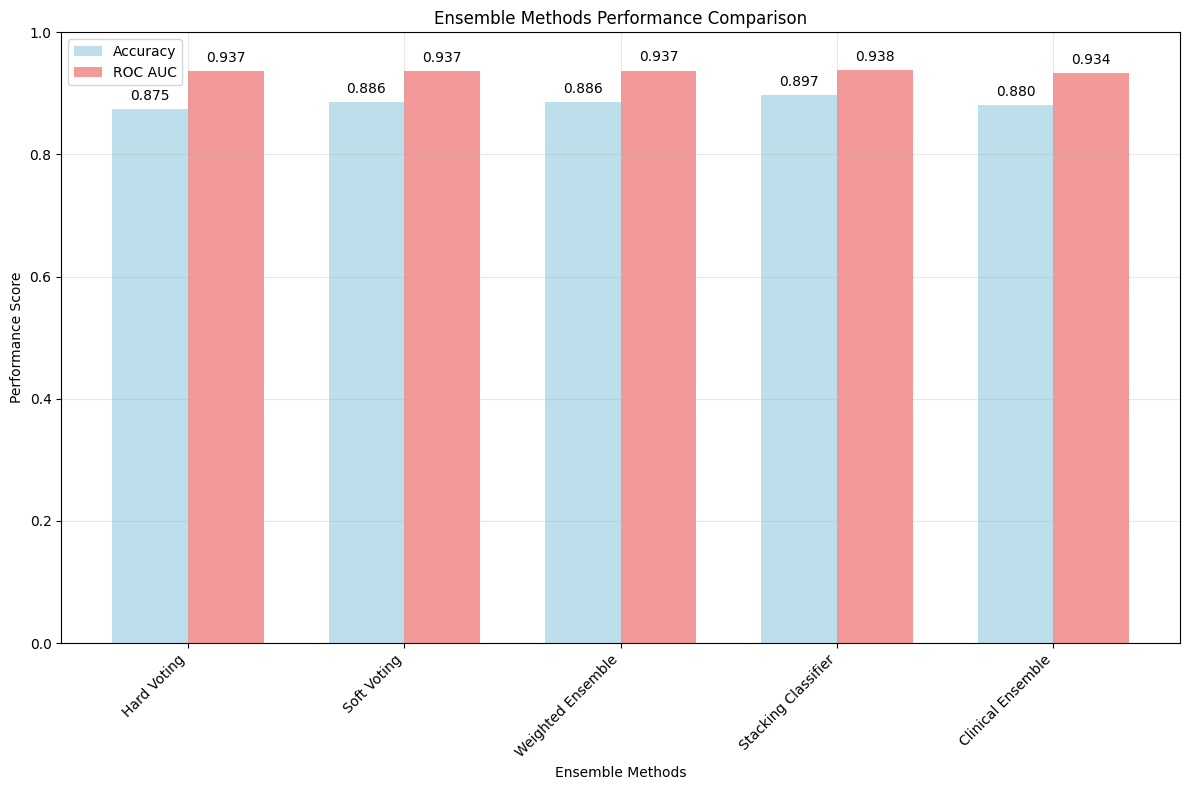

In [87]:
# This is performance comparison chart
plt.figure(figsize=(12, 8))

methods = list(ensemble_results.keys())
accuracies = [ensemble_results[method]['accuracy'] for method in methods]
aucs = [ensemble_results[method]['roc_auc'] for method in methods]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8, color='lightblue')
plt.bar(x + width/2, aucs, width, label='ROC AUC', alpha=0.8, color='lightcoral')

for i, (acc, auc) in enumerate(zip(accuracies, aucs)):
    plt.text(i - width/2, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')
    plt.text(i + width/2, auc + 0.01, f'{auc:.3f}', ha='center', va='bottom')

plt.xlabel('Ensemble Methods')
plt.ylabel('Performance Score')
plt.title('Ensemble Methods Performance Comparison')
plt.xticks(x, methods, rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

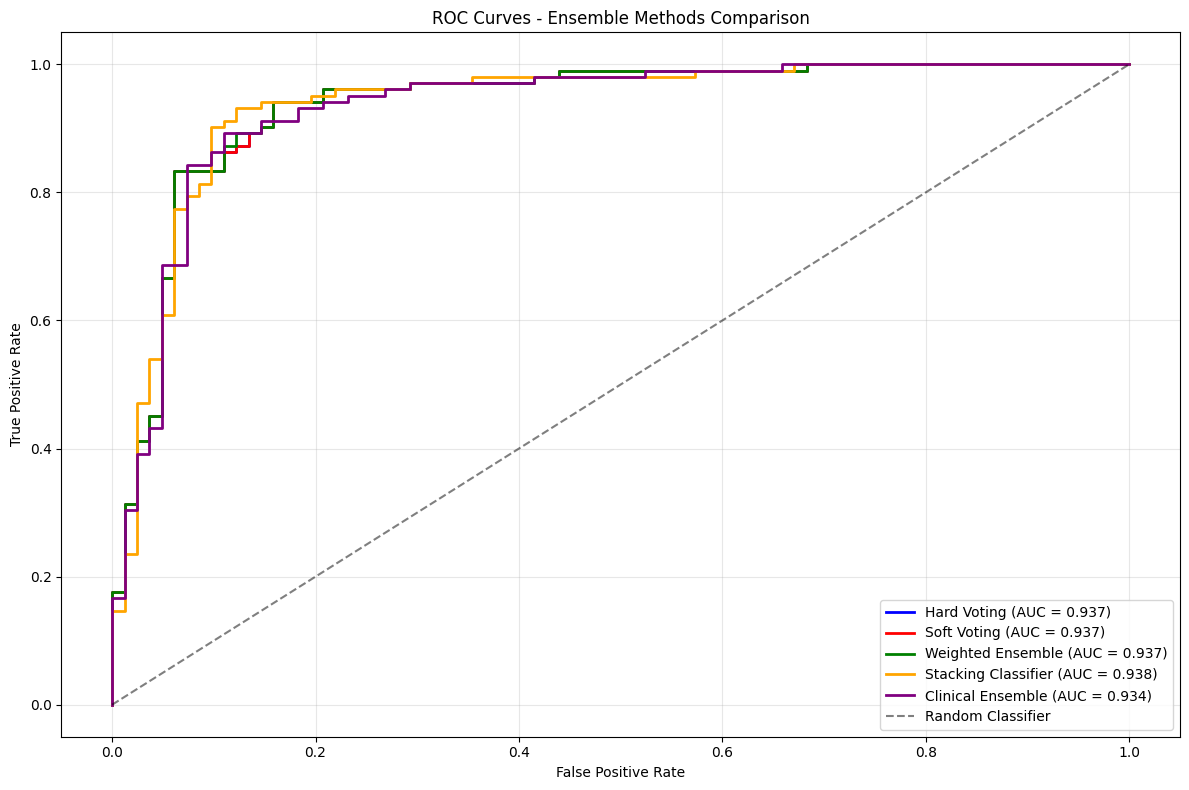

In [88]:
# This is the ROC Curves for all ensemble methods
plt.figure(figsize=(12, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (name, results) in enumerate(ensemble_results.items()):
    fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {results["roc_auc"]:.3f})',
             color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Ensemble Methods Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
